# 《生物医学图像处理》实验五 实验报告

姓名：林亨  学号：3230103696  专业：生物医学工程

**声明：本实验所有代码基于gemini 3 pro辅助完成，本人已充分理解实验代码内容**


## Project 1: Edge Detection




### 实验内容 
本实验旨在利用基于梯度算子的图像处理技术，从脑部 MRI 图像（T1 加权与 T2 加权两种模态）中提取病灶的边缘轮廓。实验核心流程包括：
1.  **预处理**：对原始数据进行归一化及 5x5 平滑滤波以抑制噪声。
2.  **梯度计算**：手动实现 Sobel 梯度核，计算图像梯度幅值。
3.  **边缘二值化**：通过设定全局阈值 $T$ 获取初步边缘掩膜。
4.  **边缘优化**：去除大脑最外圈的高亮边缘（头骨/皮层），减少非目标干扰。
5.  **形态学处理**：执行闭运算连接断裂的边缘点。
6.  **目标提取**：通过连通域分析筛选出候选病灶边缘。

### 实验原理
*   **5x5 平滑滤波**：通过空间域卷积降低图像的高频噪声。由于 Sobel 算子本质上是导数运算，对噪声极其敏感，平滑是保证边缘连续性的前提。
*   **Sobel 算子**：使用水平核 $G_x$ 和垂直核 $G_y$ 分别提取图像在两个方向的亮度变化。
    $$G_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}, \quad G_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}$$
    最终梯度幅值 $M = \sqrt{G_x^2 + G_y^2}$。
*   **闭运算**：先膨胀后腐蚀。其作用是“桥接”裂缝，能够将 Sobel 提取出的碎裂边缘线段连接成相对完整的环状。
*   **连通域分析**：根据像素的邻接关系标记集合。通过计算连通块的面积（像素数）来剔除细小的噪点，保留具有解剖意义的结构（病灶边缘）。

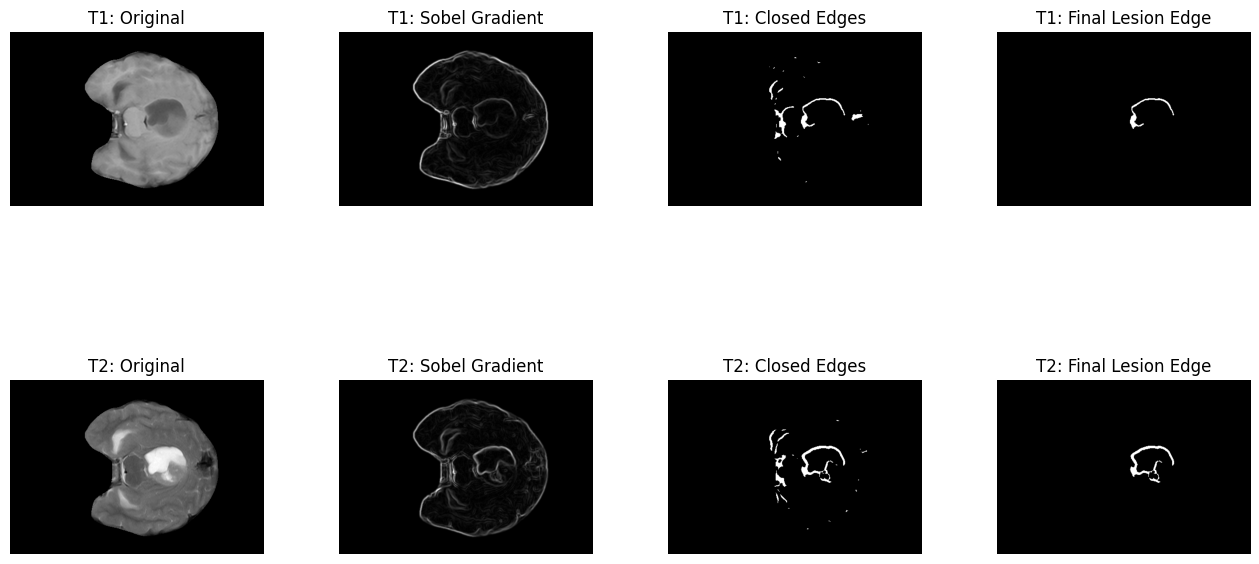

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
import os

def apply_sobel_kernel(image):
    """
    实现 Sobel 梯度核计算
    """
    Kx = np.array([[-1, 0, 1], 
                   [-2, 0, 2], 
                   [-1, 0, 1]], dtype=np.float32)
    
    Ky = np.array([[-1, -2, -1], 
                   [ 0,  0,  0], 
                   [ 1,  2,  1]], dtype=np.float32)
    
    Gx = convolve2d(image, Kx, mode='same', boundary='symm')
    Gy = convolve2d(image, Ky, mode='same', boundary='symm')
    
    magnitude = np.sqrt(Gx**2 + Gy**2)
    
    if magnitude.max() > 0:
        magnitude = (magnitude / magnitude.max()) * 255
        
    return magnitude.astype(np.uint8)

def segment_lesion_edge_only(img, threshold_T):
    # 1. 5x5 平滑滤波器
    img_smooth = cv2.GaussianBlur(img, (5, 5), 0)
    
    # 2. Sobel 滤波器
    grad_mag = apply_sobel_kernel(img_smooth)
    
    # 3. 阈值 T
    _, edge_mask = cv2.threshold(grad_mag, threshold_T, 255, cv2.THRESH_BINARY)
    
    # 4. 去除大脑外围边缘
    # 获取大脑主体区域，用较大的核进行腐蚀，彻底排除头骨和皮层边缘
    _, brain_mask = cv2.threshold(img_smooth, 20, 255, cv2.THRESH_BINARY)
    kernel_erode = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
    brain_core = cv2.erode(brain_mask, kernel_erode, iterations=1)
    
    internal_edges = cv2.bitwise_and(edge_mask, brain_core)
    
    # 5. 闭运算
    # 注意：这里缩小了闭运算的核 (5x5 或 7x7)，为了连接断点，同时防止边缘线糊成一团厚厚的面
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    closed_edges = cv2.morphologyEx(internal_edges, cv2.MORPH_CLOSE, kernel_close)
    
    # 6. 连通域处理 (提取病灶边缘环)
    # 对线段进行连通域分析
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(closed_edges, connectivity=8)
    
    lesion_edge_mask = np.zeros_like(img)
    valid_labels = []
    
    for i in range(1, num_labels): # 跳过背景(0)
        area = stats[i, cv2.CC_STAT_AREA] # 这里的 area 实际上是这条“线”包含的像素个数
        # 过滤掉细碎的短线(噪点)，保留较长的边缘线
        if 150 < area < 3000:
            valid_labels.append(i)
            
    if valid_labels:
        # 在符合长度的边缘线中，取像素最多(最长/最完整)的那条作为病灶轮廓
        best_label = max(valid_labels, key=lambda x: stats[x, cv2.CC_STAT_AREA])
        lesion_edge_mask[labels == best_label] = 255
        
    return grad_mag, closed_edges, lesion_edge_mask

def main():
    if not (os.path.exists('T1.npy') and os.path.exists('T2.npy')):
        print("请确保 T1.npy 和 T2.npy 在当前目录下。")
        return

    img_t1 = np.load('T1.npy')
    img_t2 = np.load('T2.npy')
    
    img_t1 = cv2.normalize(img_t1, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    img_t2 = cv2.normalize(img_t2, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # 阈值可根据实际效果微调
    T1_THRESHOLD = 45
    T2_THRESHOLD = 55 

    t1_grad, t1_edges, t1_lesion = segment_lesion_edge_only(img_t1, T1_THRESHOLD)
    t2_grad, t2_edges, t2_lesion = segment_lesion_edge_only(img_t2, T2_THRESHOLD)

    # ================= 结果可视化 =================
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    
    titles = ['Original', 'Sobel Gradient', 'Closed Edges', 'Final Lesion Edge']
    
    images_t1 = [img_t1, t1_grad, t1_edges, t1_lesion]
    for i in range(4):
        axes[0, i].imshow(images_t1[i], cmap='gray')
        axes[0, i].set_title(f'T1: {titles[i]}')
        axes[0, i].axis('off')
        
    images_t2 = [img_t2, t2_grad, t2_edges, t2_lesion]
    for i in range(4):
        axes[1, i].imshow(images_t2[i], cmap='gray')
        axes[1, i].set_title(f'T2: {titles[i]}')
        axes[1, i].axis('off')

    plt.show()

if __name__ == "__main__":
    main()

### 实验结果与分析

#### T1 与 T2 提取效果对比
*   **T2 模态效果显著优于 T1**：
    *   **T2 图像**中，病灶（肿瘤及周围水肿）呈现明显的**高信号（亮色）**，与周围正常的脑组织（灰色）形成了极强的对比。因此，Sobel 算子在病灶边界能捕捉到非常清晰、连续的梯度峰值。
    *   **T1 图像**中，病灶呈现**低信号（暗色）**，且其灰度级与周围的灰质、脑沟回非常接近。这导致 Sobel 算子提取出的病灶边缘非常微弱，且极易混杂在大脑内部结构的纹理边缘中。
*   **可视化表现**：
    *   T2 的呈现出一个相对清晰的“环状”，但仍然与准确的边缘有较大差距；而 T1 的最终结果中，病灶边缘破碎严重，且包含了大量无关的解剖碎块。

#### 边缘提取效果不佳的原因分析

实验中，可以明显看到病灶的边缘提取效果并不是特别好。T1和T2提取出来的病灶边缘都没有闭合，且均未提取到完整的边缘。可能的原因如下：
1.  **灰度不均与梯度缺失**：病灶边缘并非在 360° 方向上都有剧烈的灰度变化。在某些局部，病灶与正常组织的灰度完全一致，导致 Sobel 算子在该处无法产生梯度，形成“物理断层”。
2.  **脑部解剖结构的干扰**：脑沟（沟壑）和脑回（褶皱）在 Sobel 梯度图中也会产生强烈的边缘响应。对于 T1 图像，这些结构的梯度往往强于病灶边缘，导致连通域筛选时难以通过“面积”这一单一维度将其剔除。
3.  **全局阈值 $T$ 的局限性**：实验采用了全局统一阈值。然而，图像不同区域的对比度不同，固定的 $T$ 难以同时满足“保留微弱病灶边缘”和“抑制背景噪声”的需求。
4.  **闭运算核的大小矛盾**：若闭运算内核太小，无法连接巨大的断层；若内核太大，则会使原本精细的边缘线变成肥大的块状，失去边缘的几何特征。

#### 算法改进思路
1.  **对比度增强**：在 Sobel 运算前，对原始图像进行 CLAHE（限制对比度自适应直方图均衡化）。这能人为拉大病灶与背景的灰度差，尤其对提升 T1 模态的效果至关重要。
2.  **多尺度边缘融合**：结合 Canny 算子或 Laplacian 算子。Canny 算子包含非极大值抑制，能产生更细、更准确的边缘，有助于提升结果的精细度。
3.  **空洞填充与细化**：在获得闭合边缘后，可以先执行孔洞填充得到实心掩膜，再通过形态学骨架提取还原回单像素宽度的完美边缘线。
4.  **局部自适应阈值**：替代全局阈值 $T$，根据像素邻域的分布动态计算阈值，以适应 MRI 图像信号不均的特性。
5.  **引入先验空间位置**：由于病灶通常位于大脑内部特定区域，可以在筛选连通域时加入“质心位置”约束，剔除靠近边缘的无关干扰。



## Project 2: Thresholding



### 实验内容
本实验重点研究图像分割中的阈值处理技术，通过对比手动实现的两种经典算法，探究其在不同 MRI 模态下的表现：
1.  **迭代全局阈值分割 (Iterative Global Thresholding)**：实现自动化寻找阈值的迭代过程，并测试不同初始阈值 $T_{init}$（本实验选择60, 125, 190）对最终分割结果及算法收敛性的影响。
2.  **大津法 (Otsu's Optimum Thresholding)**：通过最大化类间方差（Between-class Variance）自动寻找最优阈值，并绘制类间方差曲线以验证结果。
3.  **对比分析**：针对 T1 和 T2 脑部 MRI 图像，分析两种算法在提取病灶及脑组织结构上的差异。

### 实验原理

#### 迭代全局阈值法
该算法是一种基于图像整体灰度分布的启发式搜索方法，步骤如下：
*   **初始设置**：选择一个初始阈值 $T$（通常取图像灰度的平均值或中值）。
*   **分割与均值计算**：根据 $T$ 将图像像素分为 $G_1$（大于 $T$）和 $G_2$（小于等于 $T$）两部分。分别计算这两部分的平均灰度值 $\mu_1$ 和 $\mu_2$。
*   **更新阈值**：计算新的阈值 $T_{new} = \frac{\mu_1 + \mu_2}{2}$。
*   **收敛判定**：重复上述过程，直到 $|T - T_{new}|$ 小于预设的极小值 $\Delta$。

#### 大津法 (Otsu's Method)
大津法被公认为全局阈值选择的最佳算法之一，其核心是寻找使“类间方差”最大的阈值 $k$。
*   **公式**：类间方差 $\sigma_B^2(k) = w_1(k)w_2(k)[\mu_1(k) - \mu_2(k)]^2$。
    *   其中 $w_1, w_2$ 分别是背景和前景像素占整幅图像的比例。
    *   $\mu_1, \mu_2$ 是这两部分的平均灰度。
*   **最优性**：当类间方差最大时，意味着目标和背景之间的差别最明显，错分概率最小。



### 实验过程（代码编写）

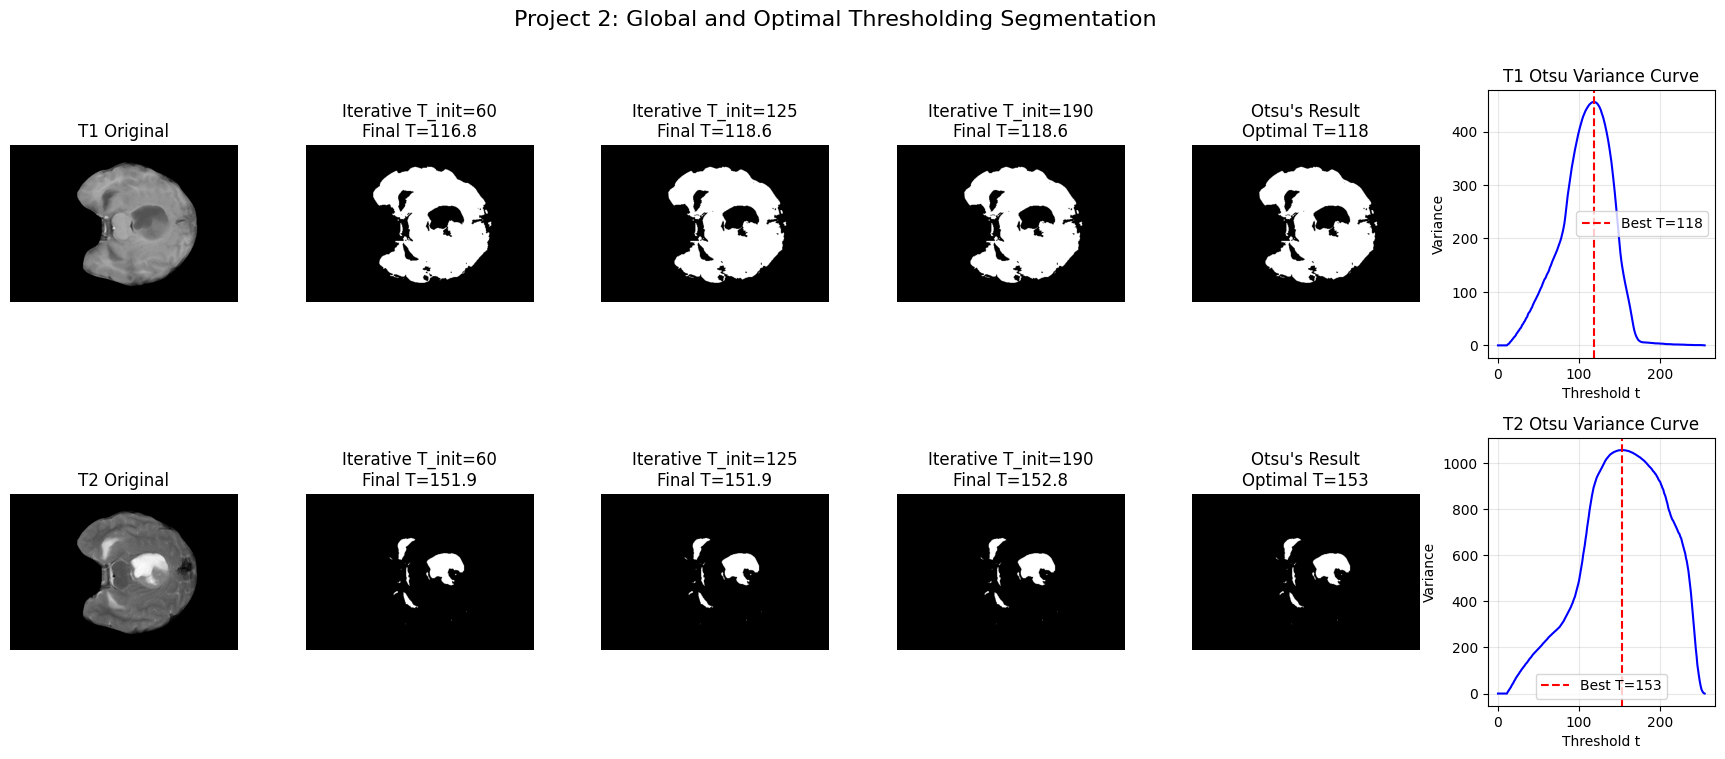

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

def iterative_threshold_manual(image, initial_T, delta=0.5):
    """
    实现迭代全局阈值分割
    """
    # 排除背景像素(<=10)，仅对脑组织进行计算
    pixels = image[image > 10].astype(np.float32)
    if len(pixels) == 0: return 0
    
    T = float(initial_T)
    while True:
        # 分为两类
        g1 = pixels[pixels > T]
        g2 = pixels[pixels <= T]
        
        # 计算均值
        mu1 = np.mean(g1) if len(g1) > 0 else 0
        mu2 = np.mean(g2) if len(g2) > 0 else 0
        
        T_new = (mu1 + mu2) / 2.0
        
        # 判断收敛
        if abs(T - T_new) < delta:
            break
        T = T_new
    return T

def otsu_threshold_manual(image):
    """
    手动实现 Otsu 最优阈值算法，并返回方差曲线
    """
    # 排除背景像素，只统计脑组织部分
    brain_pixels = image[image > 10]
    total_pixels = brain_pixels.size
    
    # 计算直方图
    hist = np.histogram(brain_pixels, bins=256, range=(0, 256))[0]
    
    variances = np.zeros(256)
    max_variance = -1
    best_T = 0
    
    # 遍历所有可能的阈值 t
    for t in range(1, 255):
        # 计算 w0, w1 (类概率权重)
        w0 = np.sum(hist[:t]) / total_pixels
        w1 = np.sum(hist[t:]) / total_pixels
        
        if w0 == 0 or w1 == 0:
            continue
            
        # 计算 mu0, mu1 (类平均灰度)
        mu0 = np.sum(np.arange(t) * hist[:t]) / (w0 * total_pixels)
        mu1 = np.sum(np.arange(t, 256) * hist[t:]) / (w1 * total_pixels)
        
        # 计算类间方差 sigma_b^2
        variance = w0 * w1 * ((mu0 - mu1) ** 2)
        variances[t] = variance
        
        if variance > max_variance:
            max_variance = variance
            best_T = t
            
    return best_T, variances

def main():
    # 检查数据
    if not (os.path.exists('T1.npy') and os.path.exists('T2.npy')):
        print("请确保数据文件 T1.npy 和 T2.npy 在当前目录下。")
        return

    # 加载并归一化到 0-255
    img_t1 = cv2.normalize(np.load('T1.npy'), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    img_t2 = cv2.normalize(np.load('T2.npy'), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # 设定三个不同的初始 T 值
    initial_Ts = [60, 125, 190]
    
    # 绘图设置：2行(T1, T2) x 6列(原图, 3个迭代结果, Otsu结果, 方差曲线)
    fig, axes = plt.subplots(2, 6, figsize=(22, 8))
    plt.subplots_adjust(wspace=0.3, hspace=0.3)

    for row, img, label in zip([0, 1], [img_t1, img_t2], ['T1', 'T2']):
        # 1. 原始图像
        axes[row, 0].imshow(img, cmap='gray')
        axes[row, 0].set_title(f"{label} Original")
        
        # 2. 迭代法：三个不同的初始 T 值
        for i, t_init in enumerate(initial_Ts):
            t_final = iterative_threshold_manual(img, t_init)
            _, bin_img = cv2.threshold(img, t_final, 255, cv2.THRESH_BINARY)
            axes[row, i+1].imshow(bin_img, cmap='gray')
            axes[row, i+1].set_title(f"Iterative T_init={t_init}\nFinal T={t_final:.1f}")
        
        # 3. Otsu 法结果
        otsu_t, variances = otsu_threshold_manual(img)
        _, otsu_bin = cv2.threshold(img, otsu_t, 255, cv2.THRESH_BINARY)
        axes[row, 4].imshow(otsu_bin, cmap='gray')
        axes[row, 4].set_title(f"Otsu's Result\nOptimal T={otsu_t}")
        
        # 4. Otsu 类间方差曲线
        axes[row, 5].plot(variances, color='blue', linewidth=1.5)
        axes[row, 5].axvline(otsu_t, color='red', linestyle='--', label=f'Best T={otsu_t}')
        axes[row, 5].set_title(f"{label} Otsu Variance Curve")
        axes[row, 5].set_xlabel("Threshold t")
        axes[row, 5].set_ylabel("Variance")
        axes[row, 5].legend()
        axes[row, 5].grid(True, alpha=0.3)

    # 隐藏图像部分的坐标轴
    for ax in axes[:, :5].flatten():
        ax.axis('off')

    plt.suptitle("Project 2: Global and Optimal Thresholding Segmentation", fontsize=16)
    plt.show()

if __name__ == "__main__":
    main()

### 实验结果与分析

#### 初始阈值 $T_{init}$ 对迭代法的影响
根据实验结果图分析：
*   **收敛稳定性**：在 **T1 图像**中，$T_{init}$ 分别取 60, 125, 190，最终得到的收敛阈值 $T$ 分别为 **116.8, 118.6, 118.6**。在 **T2 图像**中，最终阈值均稳定在 **151.9** 附近。
*   **结论**：迭代阈值法的初始阈值的选取虽然不同，但算法最终都能收敛到极为接近的全局平衡点，对最终分割视觉效果的影响微乎其微。

#### T1 与 T2 模态的分割效果差异
*   **T2 模态效果较好**：由于 T2 图像中的病灶呈高亮信号，其灰度级处于直方图的高端。无论是迭代法还是 Otsu 法，选取的阈值（约 152-153）均能精准地将高亮的病灶和脑脊液从背景中提取出来。
*   **T1 模态效果有限**：T1 图像中病灶通常表现为低信号（黑影）。由于全局阈值分割本质上是提取亮部目标，因此在 T1 中，病灶被归类为背景，而算法提取出的是白质等较亮组织。实验结果显示，T1 的分割结果主要呈现了脑部的基本解剖轮廓，无法像 T2 那样直接通过阈值定位病灶。

#### Otsu 法与迭代法的效果比较
*   **结果数值**：从图中可见，在 T1 中，迭代法最终 $T \approx 118.6$，Otsu $T=118$；在 T2 中，迭代法 $T \approx 151.9$，Otsu $T=153$。
*   **视觉一致性**：两者得到的二值化图像在视觉上几乎没有区别，说明在脑部 MRI 这种目标与背景差异明显的图像中，两者的性能表现高度趋同。



#### 算法优缺点说明

| 算法 | 优点 | 缺点 |
| :--- | :--- | :--- |
| **迭代阈值法** | 1. 原理简单，计算开销极小。<br>2. 逻辑直观，通过物理意义上的“中点”寻找平衡。<br>3. 对初始值不敏感，收敛速度快。 | 1. 属于启发式方法，缺乏严格的统计学证明其为最优解。<br>2. 在多噪声或灰度分布极度不均时，可能陷入局部震荡。 |
| **大津法 (Otsu)** | 1. **全自动**，无需设置任何初值。<br>2. **数学严谨**，基于类间方差最大化，具有理论上的最优性。<br>3. 适应性广，对直方图双峰明显的图像效果极佳。 | 1. 计算量相对略大（需遍历 0-255 灰度级）。<br>2. 当目标与背景的面积比例极其悬殊时，阈值会向面积大的一方偏移，导致分割失败。 |



## Project 3: Segmentation



### 实验内容
本实验旨在研究和实现多种高级图像分割算法，以实现对脑部 T2 影像中病灶区域的精准提取与体积定量计算。实验内容包括：
1.  **区域生长 (Region Growing)**：利用交互式选取的种子点，根据灰度相似性准则进行区域扩张。
2.  **标准 K-means 聚类**：仅基于像素灰度特征将图像划分为 $K$ 个簇。
3.  **改进 K-means 聚类**：构建包含灰度和空间坐标 $(x, y)$ 的多维特征向量，测试不同聚类数 $K$ 与空间权重 $W$ 的组合。
4.  **分水岭算法 (Watershed)**：利用形态学梯度作为地形，结合手动标记（Markers）解决过度分割问题。
5.  **体积定量化**：根据 $1\text{mm} \times 1\text{mm}$ 的分辨率计算各方法提取的病灶体积（$mm^3$）。

### 实验原理

#### 区域生长 (Region Growing)
*   **核心逻辑**：从指定的种子点 $S$ 开始，检查邻域像素 $P$。若 $|I(P) - I(S)| \leq \text{Tolerance}$，则将 $P$ 合并入区域。
*   **公式**：区域集合 $R$ 满足 $\forall P \in R, |f(P) - \mu_R| \leq T$。

#### 改进 K-means 聚类
*   **特征扩展**：将单一灰度特征扩展为三维向量 $V = [I, W \cdot X, W \cdot Y]$。
*   **距离度量**：使用欧氏距离进行分配
*   **空间权重 $W$ 的意义**：当 $W > 0$ 时，算法不仅考虑像素“有多亮”，还考虑像素“在哪里”，从而增强聚类结果的空间连通性。

#### 分水岭算法 (Watershed)
*   **地形概念**：将图像梯度幅值视为地形高度，局部极小值点作为集水盆地的中心。
*   **改进策略**：引入手动 Markers（前景种子与背景种子），通过控制注水起始点，强制算法在特定边界处停止，从而克服传统分水岭对噪声敏感导致的“过度分割”。



>>> 请在弹出窗口点击病灶中心...
>>> 正在运行区域生长，请调整滑动条后按【回车键】确认...
>>> 正在进行 K-Means 多参数对比测试...

      病灶体积统计报告 (mm²)
分割方法                           | 体积 (mm²)  
---------------------------------------------
区域生长 (Region Growing)          | 2469      
分水岭 (Watershed)                | 3095      
---------------------------------------------
Standard (K=3)                 | 4594      
Improved (K=3, W=0.1)          | 5060      
Improved (K=3, W=0.2)          | 5174      
Standard (K=5)                 | 3452      
Improved (K=5, W=0.1)          | 4164      
Improved (K=5, W=0.2)          | 5647      
Standard (K=7)                 | 3250      
Improved (K=7, W=0.1)          | 4195      
Improved (K=7, W=0.2)          | 4749      

[完成] 图像已生成。请查看对比图表并关闭窗口结束程序。


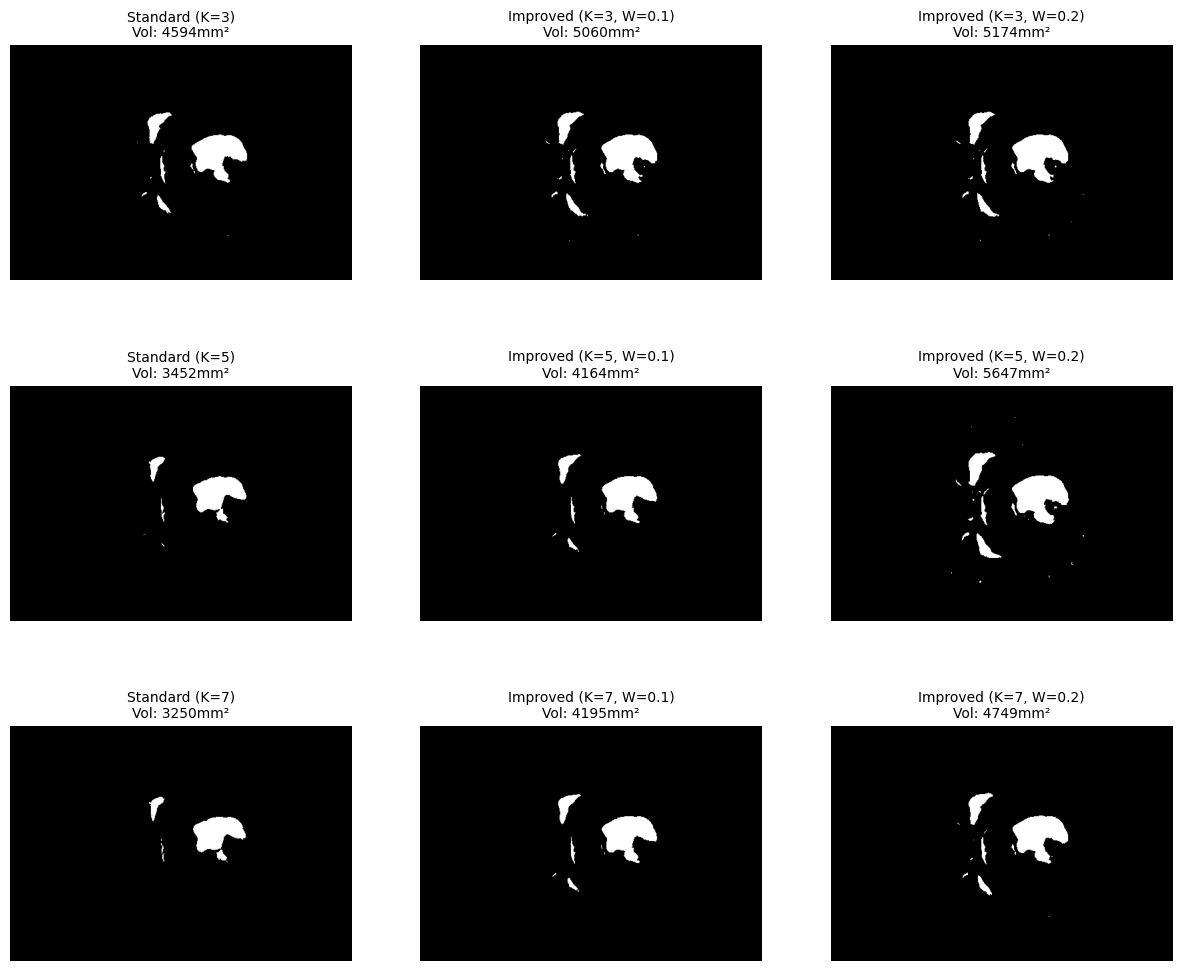

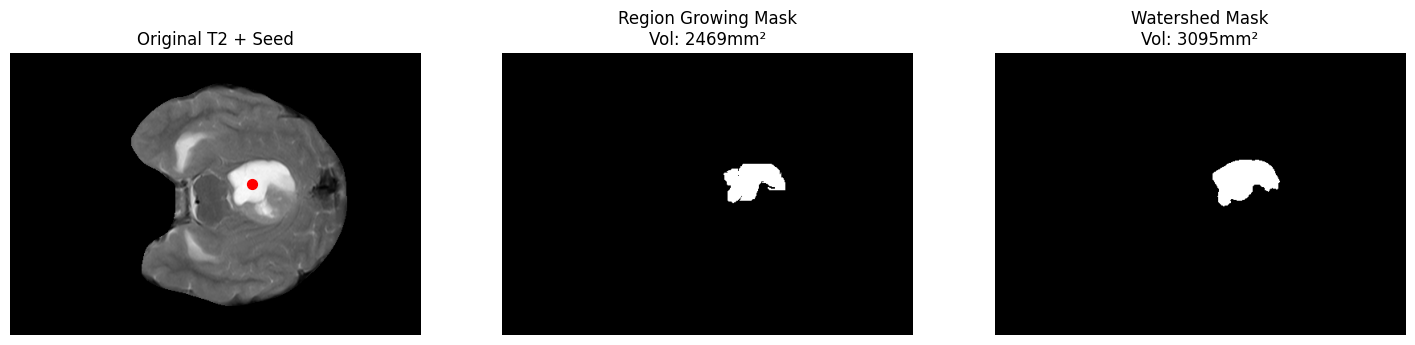

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

# 全局变量
seed_point = None
img_t2 = None

def get_kmeans_mask(img, k, w_spatial, seed_x, seed_y):
    """手动实现改进 K-means：灰度 + 空间坐标"""
    h, w = img.shape
    y_idx, x_idx = np.indices((h, w))
    # 构建特征向量：[灰度, 归一化x*权重, 归一化y*权重]
    data = np.stack([
        img.flatten() / 255.0, 
        (x_idx.flatten() / w) * w_spatial, 
        (y_idx.flatten() / h) * w_spatial
    ], axis=1).astype(np.float32)
    
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
    _, labels, _ = cv2.kmeans(data, k, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
    labels = labels.reshape((h, w))
    
    # 根据种子点坐标提取对应的聚类簇
    target_label = labels[seed_y, seed_x]
    mask = np.zeros_like(img)
    mask[labels == target_label] = 255
    return mask, labels

def main():
    global seed_point, img_t2
    if not os.path.exists('T2.npy'): 
        print("错误：未找到 T2.npy 文件")
        return

    # 1. 预处理
    raw = np.load('T2.npy')
    img_t2 = cv2.normalize(raw, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    h, w = img_t2.shape

    # 2. 交互选取种子点
    print(">>> 请在弹出窗口点击病灶中心...")
    cv2.imshow("1. Click Lesion Center", img_t2)
    def on_click(event, x, y, flags, param):
        global seed_point
        if event == cv2.EVENT_LBUTTONDOWN:
            seed_point = (x, y)
            cv2.destroyWindow("1. Click Lesion Center")
    cv2.setMouseCallback("1. Click Lesion Center", on_click)
    cv2.waitKey(0)
    
    if seed_point is None: 
        print("未选取种子点，程序退出。")
        return
    sx, sy = seed_point

    # 3. 区域生长：带滑动条实时调优
    print(">>> 正在运行区域生长，请调整滑动条后按【回车键】确认...")
    cv2.namedWindow("2. Adjust Region Growing")
    cv2.createTrackbar("Tol", "2. Adjust Region Growing", 15, 50, lambda x: None)
    
    mask_rg = np.zeros_like(img_t2)
    final_rg_vol = 0
    while True:
        tol = cv2.getTrackbarPos("Tol", "2. Adjust Region Growing")
        ff_mask = np.zeros((h + 2, w + 2), np.uint8)
        flags = 4 | (255 << 8) | cv2.FLOODFILL_MASK_ONLY
        cv2.floodFill(img_t2, ff_mask, (sx, sy), 0, (tol,), (tol,), flags)
        mask_rg = ff_mask[1:-1, 1:-1]
        final_rg_vol = np.sum(mask_rg == 255)
        
        preview = cv2.cvtColor(img_t2, cv2.COLOR_GRAY2BGR)
        preview[mask_rg == 255] = [0, 0, 255] 
        cv2.putText(preview, f"Vol: {final_rg_vol}mm2", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 2)
        cv2.imshow("2. Adjust Region Growing", preview)
        
        key = cv2.waitKey(1) & 0xFF
        if key == 13: # 回车确认
            cv2.destroyAllWindows()
            break

    # 4. 改进 K-Means 多参数对比测试
    print(">>> 正在进行 K-Means 多参数对比测试...")
    k_values = [3, 5, 7]
    weights = [0.0, 0.1, 0.2] 
    kmeans_results = [] # 用于最后输出体积

    km_fig, km_axes = plt.subplots(len(k_values), len(weights), figsize=(15, 12))
    plt.subplots_adjust(hspace=0.4)
    
    for i, k in enumerate(k_values):
        for j, w_s in enumerate(weights):
            mask, _ = get_kmeans_mask(img_t2, k, w_s, sx, sy)
            vol = np.sum(mask == 255)
            
            # 记录结果
            method_name = f"Standard (K={k})" if w_s == 0 else f"Improved (K={k}, W={w_s})"
            kmeans_results.append((method_name, vol))
            
            km_axes[i, j].imshow(mask, cmap='gray')
            km_axes[i, j].set_title(f"{method_name}\nVol: {vol}mm²", fontsize=10)
            km_axes[i, j].axis('off')

    # 5. 分水岭 (Watershed)
    _, brain_mask = cv2.threshold(img_t2, 20, 255, cv2.THRESH_BINARY)
    markers = np.zeros(img_t2.shape, dtype=np.int32)
    markers[brain_mask == 0] = 1 
    cv2.circle(markers, (sx, sy), 5, 2, -1) 
    
    gradient = cv2.morphologyEx(img_t2, cv2.MORPH_GRADIENT, np.ones((3,3)))
    cv2.watershed(cv2.cvtColor(gradient, cv2.COLOR_GRAY2BGR), markers)
    mask_water = np.zeros_like(img_t2)
    mask_water[markers == 2] = 255
    water_vol = np.sum(mask_water == 255)

    # 6. 最终展示图
    res_fig, res_axes = plt.subplots(1, 3, figsize=(18, 6))
    res_axes[0].imshow(img_t2, cmap='gray')
    res_axes[0].scatter(sx, sy, c='red', s=50, label='Seed')
    res_axes[0].set_title("Original T2 + Seed")
    
    res_axes[1].imshow(mask_rg, cmap='gray')
    res_axes[1].set_title(f"Region Growing Mask\nVol: {final_rg_vol}mm²")
    
    res_axes[2].imshow(mask_water, cmap='gray')
    res_axes[2].set_title(f"Watershed Mask\nVol: {water_vol}mm²")
    
    for ax in res_axes: ax.axis('off')
    
    # 7. 控制台输出体积统计结果
    print("\n" + "="*40)
    print("      病灶体积统计报告 (mm²)")
    print("="*40)
    print(f"{'分割方法':<30} | {'体积 (mm²)':<10}")
    print("-" * 45)
    print(f"{'区域生长 (Region Growing)':<30} | {final_rg_vol:<10}")
    print(f"{'分水岭 (Watershed)':<30} | {water_vol:<10}")
    print("-" * 45)
    for name, v in kmeans_results:
        print(f"{name:<30} | {v:<10}")
    print("="*40)

    print("\n[完成] 图像已生成。请查看对比图表并关闭窗口结束程序。")
    plt.show()

if __name__ == "__main__":
    main()

### 实验结果与分析


#### 区域生长算法分析
*   **提取效果**：在容忍度设置合理且种子点位于病灶核心时，能快速提取出连通性极好的病灶区域。
*   **缺陷分析**：由于 T2 影像中脑脊液同样具有高亮特征，若容忍度稍大，病灶区域会顺着亮度接近的脑脊液发生“泄漏”，导致提取体积异常增大（溢出）。
*   **体积表现**：通常较为稳定，但在病灶内部灰度不均时，容易出现内部空洞。而且无法完整提取病灶。

#### 分水岭算法分析
在 T2 影像中，分水岭算法计算出的体积小于 K-means，原因如下：

* **梯度阻断**：分水岭算法是在梯度图上运行的。病灶（肿瘤）内部往往存在灰度不均，如果病灶内部存在一个局部的强梯度（即亮度突变点），分水岭的“水流”会被这些内部的“高山”阻断，导致它只能充满最核心的区域，而无法向真实的病灶边缘扩张。

* **保守分割特性**：分水岭非常依赖 Marker（种子点）的设置。如果种子点仅设在病灶的最核心，而病灶边缘的梯度响应较弱（边缘模糊），算法会倾向于在最明显的内部脊线处停止。这导致它只提取了病灶的核心高亮部分，而丢失了周围灰度略低、但仍属于病灶的边缘水肿区。

* **欠分割问题**：相比于 K-means 的区域统计特性，分水岭更像是一种“边缘检测”的延伸。它对局部极值非常敏感，容易陷入局部解，从而产生体积偏小的结果。

#### 改进 K-means 算法参数测试与分析
实验测试了 $K=\{3, 5, 7\}$ 与 $W=\{0.0, 0.1, 0.2\}$ 的组合：
*   **K 值的影响**：
    *   $K=3$ 时，分类过于粗糙，病灶常与正常脑组织混淆。
    *   $K=5$ 或 $7$ 时，病灶能作为独立的高亮度簇被分离，效果更佳。
*   **空间权重 $W$ 的影响**：
    *   当 **$W$ 增大**时，聚类簇的形状会变得越来越规整（趋于圆形），这有助于去除病灶外的飞地噪点。
    *   **但 $W$ 过大会导致错误提取**：因为算法此时极度依赖空间距离。如果种子点附近的正常脑组织（非病灶区）在空间上离病灶核心很近，即便它们的灰度并不属于高亮区，也会被算法强行“拉入”病灶簇中。这会导致病灶边缘过度向外扩张，提取出非病灶区域，从而使体积数值虚高。
*   **最佳效果组**：**$K=5, W=0.1$**。这一组参数在保证病灶完整性的同时，较好地平衡了灰度准确性和空间连通性，没有出现严重的条纹现象。



#### 各算法比较与应用场景

| 算法 | 优点 | 缺点 | 应用场景 |
| :--- | :--- | :--- | :--- |
| **区域生长** | 保证结果的强连通性，适合提取单一组织。 | 对种子点极度敏感，易发生泄漏。 | 边界清晰、背景简单的病灶提取。 |
| **标准 K-means** | 无需手动设点，计算速度快。 | 结果破碎，受噪声影响大，无法区分不同位置的亮区。 | 图像初步分类、多组织普查。 |
| **改进 K-means** | 结果圆润连续，能剔除远处噪点干扰。 | **$W$ 过大会引入非病灶区**，产生几何畸变。 | 存在信号不均、需平滑边缘的病灶分割。 |
| **分水岭算法** | 边缘定位最精准，能处理粘连。 | 极易过度分割，参数调整极其复杂。 | 对体积精确度要求极高的解剖结构分割。 |




# 实验心得


本实验围绕脑部 T1、T2 模态 MRI 图像，分阶段实现了病灶提取任务：
*   **边缘检测 (Project 1)**：基于 **Sobel 算子**提取梯度，结合**形态学闭运算**连接断裂边缘，并通过**连通域面积过滤**剔除背景噪声与解剖结构干扰。
*   **阈值分割 (Project 2)**：对比了**迭代全局阈值法**与 **Otsu 算法**。通过最大化类间方差（Between-class Variance）寻找最优切分点，并分析了背景像素对收敛阈值的影响。
*   **高级分割 (Project 3)**：实现了**区域生长**、**分水岭算法**及**改进 K-means 聚类**。重点研究了空间权重 $W$ 对聚类内聚性的贡献，并定量计算了病灶体积。

实验证明，针对病灶特征不一的 MRI 影像，单一算法难以实现全场景适用。结合空间先验的改进 K-means 在形态保持上具有优势，而分水岭算法在边界定位上更具参考价值。多算法融合对比是实现临床定量分析的必要手段。


在代码实现过程中，主要的技术挑战集中在以下两个方面：
*   **坐标索引对齐**：在处理 OpenCV 函数（遵循 `(x, y)` 坐标）与 NumPy 矩阵访问（遵循 `[row, col]` 即 `[y, x]`）时，初期的索引倒置导致种子点定位偏差。通过显式定义变量名解决了这一逻辑冲突。
*   **特征归一化**：K-means 聚类中，若未对空间坐标和灰度值进行等比例缩放，会导致特征量级失衡。通过将坐标映射至 $[0, 1]$ 区间并动态调整权重 $W$，成功解决了聚类结果中的几何畸变问题。


感谢吴丹老师在课堂上对图像处理理论的深入讲解，使我们建立了系统的知识框架；同时感谢助教学长在实验过程中提供的技术支持与反馈，帮助我们解决了诸多代码实现的细节难题。



